In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [2]:
import pandas as pd
import os

df= pd.read_csv(os.path.join(path,"heart.csv"))

In [3]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


<Axes: >

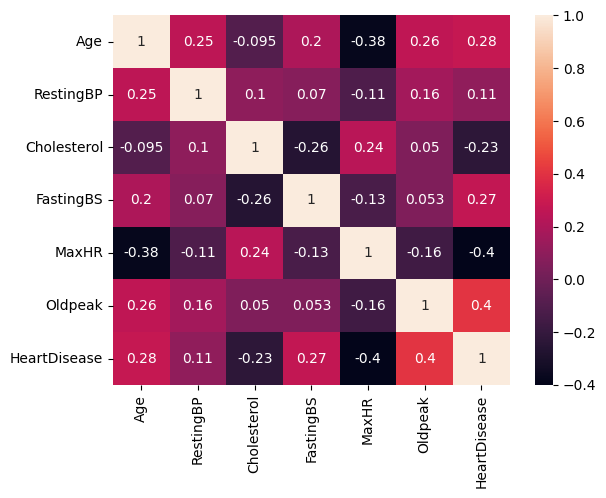

In [7]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True)

In [8]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [9]:
X = pd.get_dummies(X, drop_first=True)

print("Columns after encoding:")
print(X.columns)

Columns after encoding:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (734, 15)
Test shape: (184, 15)


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

In [13]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.8533
Decision Tree: 0.8261
Random Forest: 0.8696
SVM: 0.8750
KNN: 0.8533


In [14]:
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]


Best Model: SVM


Text(50.722222222222214, 0.5, 'True')

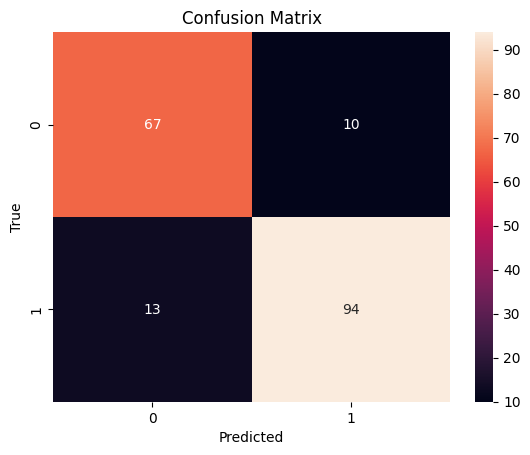

In [15]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

In [16]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [17]:
import pickle


with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)


with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns, f)

In [18]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 102.9 MB/s eta 0:00:00


In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np


try:
    from pyngrok import ngrok
    public_url = ngrok.connect(port='8501')
    st.success(f"Public URL for Streamlit App: {public_url}")
except ImportError:
    st.warning("pyngrok not installed. Streamlit app will not be publicly accessible via ngrok.")
except Exception as e:
    st.error(f"Error starting ngrok tunnel: {e}. Please ensure pyngrok is installed and ngrok is properly configured.")


with open("best_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("columns.pkl", "rb") as f:
    original_columns = pickle.load(f)
print(f"Loaded model type: {type(model)}")
print(f"Model has predict_proba attribute: {hasattr(model, 'predict_proba')}")
print(f"Model probability attribute: {getattr(model, 'probability', 'N/A')}")


st.title("❤️ Heart Disease Prediction App")

st.markdown("""
This app predicts the **likelihood of heart disease** based on a few important health parameters.
""")


st.header("Patient Information")

age = st.slider("Age", 1, 100, 50)
sex_choice = st.selectbox("Sex", ["Male", "Female"])
chest_pain_type = st.selectbox("Chest Pain Type", ["ASY (Asymptomatic)", "ATA (Typical Angina)", "NAP (Non-Anginal Pain)", "TA (Typical Angina)"])
resting_bp = st.slider("Resting Blood Pressure (mm/Hg)", 80, 200, 120)
cholesterol = st.slider("Cholesterol (mg/dl)", 100, 600, 200)
fasting_bs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", [0, 1]) # 0=False, 1=True
max_hr = st.slider("Maximum Heart Rate Achieved", 60, 220, 150)
exercise_angina_choice = st.selectbox("Exercise Induced Angina", ["No", "Yes"])
oldpeak = st.slider("Oldpeak (ST depression induced by exercise relative to rest)", 0.0, 6.2, 1.0)

input_data = {}
for col in original_columns:
    input_data[col] = 0

# Age
input_data['Age'] = age
# Sex
input_data['Sex_M'] = 1 if sex_choice == "Male" else 0
# Chest Pain Type
if "ATA" in chest_pain_type:
    input_data['ChestPainType_ATA'] = 1
elif "NAP" in chest_pain_type:
    input_data['ChestPainType_NAP'] = 1
elif "TA" in chest_pain_type:
    input_data['ChestPainType_TA'] = 1
# RestingBP
input_data['RestingBP'] = resting_bp
# Cholesterol
input_data['Cholesterol'] = cholesterol
# FastingBS
input_data['FastingBS'] = fasting_bs
# MaxHR
input_data['MaxHR'] = max_hr
# Exercise Angina
input_data['ExerciseAngina_Y'] = 1 if exercise_angina_choice == "Yes" else 0
# Oldpeak
input_data['Oldpeak'] = oldpeak


input_df = pd.DataFrame([input_data], columns=original_columns)


input_scaled = scaler.transform(input_df)

# Make prediction
prediction = model.predict(input_scaled)

# Get prediction probabilities
if hasattr(model, 'predict_proba'):
    prediction_proba = model.predict_proba(input_scaled)[:,1]
    prob_available = True
else:
    prediction_proba = np.array([0.0])
    prob_available = False
    st.warning("Probability estimation not available for the selected model. Displaying raw prediction.")

st.subheader("Prediction Result:")
if prediction[0] == 1:
    if prob_available:
        st.error(f"The model predicts **Heart Disease** with probability {prediction_proba[0]:.2f}")
    else:
        st.error(f"The model predicts **Heart Disease**.")
else:
    if prob_available:
        st.success(f"The model predicts **No Heart Disease** with probability {1-prediction_proba[0]:.2f}")
    else:
        st.success(f" The model predicts **No Heart Disease**.")


Writing app.py


In [ ]:
!pip install pyngrok

import subprocess
from pyngrok import ngrok
import time

ngrok.set_auth_token("3CJ6OSDJ9QHZJsZ2qjsnzwdAgkk_2Ftf37Fmv9Tpr6cdeLNbP")


ngrok.kill()


public_url = ngrok.connect(addr="8501")
print(f"Public URL for Streamlit App: {public_url}")


streamlit_process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"]
)


try:
    while True:
        time.sleep(100)
except KeyboardInterrupt:
    print("Stopping Streamlit and ngrok...")
finally:

    streamlit_process.terminate()
    ngrok.kill()

Public URL for Streamlit App: NgrokTunnel: "https://macie-gingival-emotionlessly.ngrok-free.dev" -> "http://localhost:8501"
